# Notebook Colab: Dataset + U-Net surrogate para C(r,t)
## - Genera dataset paramétrico (runs del solver rápido)
## - Entrena un U-Net 2D que emula C(r,t)
## - Guarda modelo y muestra ejemplos
# ==============================
### Recomendación: Runtime -> Change runtime type -> GPU
### Ejecuta celda completa (tarda según cantidad de datos y epochs)

## 👤 Juan Carlos Vega


Computer Sciences PhD Student

**IA para Energías Renovables**  
Universidad de los Andes,

2025

Este codigo hace todo lo siguiente, paso a paso:

  - Genera un dataset paramétrico usando el solver (versión rápida y estable) sobre la malla (r, t).

  - Entrena un U-Net 2D que emula C(r,t)C(r,t) (entrada: parámetros + coordenadas; salida: campo 2D).

  - Incluye funciones de pérdida (MSE + penalización de BC + optional physics residual), métricas, guardado y visualización de ejemplos inferidos vs ground truth.

  - Está configurado para funcionar en Colab con GPU (elige runtime → GPU).

In [8]:
!pip install --quiet torchviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 87.2 MB/s eta 0:00:00


In [1]:
# ------------------------------
# 0) Instalaciones (si fueran necesarias)
# ------------------------------
# En Colab la mayoría ya están; por seguridad:
!pip install --quiet einops tqdm

# ------------------------------
# 1) Imports y utilidades
# ------------------------------
import os
import math
import time
import json
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


# U-Net vs. CNN Clásica

## 1. ¿Qué es una U-Net?
La **U-Net** es una arquitectura de red neuronal convolucional diseñada principalmente para **segmentación y reconstrucción de imágenes**.  
Fue propuesta en 2015 para segmentación biomédica, pero hoy se usa en una amplia gama de problemas donde se requiere obtener una **salida con la misma resolución espacial** que la entrada (mapa píxel a píxel).

Su nombre proviene de su forma característica en **U**:
- **Camino de contracción (encoder)**: reduce la resolución y extrae características (similar a una CNN clásica).
- **Camino de expansión (decoder)**: aumenta la resolución nuevamente hasta la original, para producir un mapa de salida detallado.
- **Conexiones "skip"**: unen las capas del encoder con las del decoder en niveles equivalentes, transfiriendo **información espacial detallada** que se perdería solo con el encoder.

---

## 2. Diferencias clave con una CNN clásica

| Característica              | CNN Clásica (clasificación)                  | U-Net (segmentación/reconstrucción)       |
|-----------------------------|-----------------------------------------------|--------------------------------------------|
| **Objetivo principal**      | Asignar una etiqueta global a la imagen       | Predecir un valor/clase para cada píxel    |
| **Estructura**              | Secuencia de convoluciones y *pooling*, seguida de capas densas | Estructura en forma de U con encoder + decoder |
| **Resolución de salida**    | Muy reducida respecto a la entrada            | Igual o similar a la entrada               |
| **Conexiones "skip"**       | No existen                                   | Sí, unen capas simétricas encoder-decoder  |
| **Aplicaciones típicas**    | Clasificación de imágenes, detección de objetos | Segmentación, reconstrucción de señales, problemas inversos |
| **Pérdida de información espacial** | Alta, por reducción progresiva de tamaño | Menor, por las *skip connections*          |

---

## 3. ¿Por qué la U-Net es especial?
La U-Net combina:
1. **Capacidad de extracción de características** de una CNN profunda.
2. **Preservación de información espacial** mediante *skip connections*.
3. **Reconstrucción densa** del mapa de salida, útil cuando el valor final no es una clase global, sino un campo continuo o mapa de etiquetas.

Esto la hace ideal para:
- **Segmentación de imágenes médicas** (tumores, órganos, vasos sanguíneos).
- **Reconstrucción de datos físicos** (campos de temperatura, concentración, deformaciones).
- **Problemas de superresolución** o generación de mapas a partir de sensores limitados.

---

## 4. Resumen visual

## Diagrama visual de la arquitectura U-Net

Entrada (Imagen)
│
▼
╔════════════════════════════════════════╗
║ Camino de Contracción ║
║ (Encoder: convoluciones + pooling) ║
╚════════════════════════════════════════╝
│
▼
Representación Latente (Bottleneck)
│
▲
╔════════════════════════════════════════╗
║ Camino de Expansión ║
║ (Decoder: convoluciones transpuestas) ║
╚════════════════════════════════════════╝
│
▼
Mapa de Salida (misma resolución que entrada)

In [2]:
# ------------------------------
# 2) Solver rápido (funciones reproducibles)
#    Versión compacta y vectorizable del solver implícito 1D radial
# ------------------------------
from scipy.linalg import solve_banded

def run_diffusion_solver(Ri, Ro, Cin, Cout, D, n_r=128, nt=64, t_end_hours=5.0):
    """
    Resuelve C(r,t) en malla (n_r x nt) con esquema implícito backward-Euler.
    Retorna (r, t_hours, C) donde C.shape = (n_r, nt)
    """
    # geometry & time (use seconds internally)
    dr = (Ro - Ri) / (n_r - 1)
    r = np.linspace(Ri, Ro, n_r)
    tvec = np.linspace(0.0, t_end_hours, nt)
    S = 3600.0  # seconds per hour
    dt = (t_end_hours / (nt - 1)) * S

    # prealloc
    H = np.zeros((n_r, nt))
    C_old = np.zeros(n_r)  # initial concentration C0=0
    H[:, 0] = C_old

    # build tridiagonal bands (lower, diag, upper) then banded A
    lower = np.zeros(n_r)
    diag = np.zeros(n_r)
    upper = np.zeros(n_r)
    for i in range(1, n_r-1):
        a_i = D * (1.0/dr**2 - 1.0/(2.0 * r[i] * dr))
        b_i = -2.0 * D / dr**2
        c_i = D * (1.0/dr**2 + 1.0/(2.0 * r[i] * dr))
        lower[i] = a_i
        diag[i] = b_i - 1.0/dt
        upper[i] = c_i
    # Dirichlet BCs
    diag[0] = 1.0
    upper[0] = 0.0
    lower[0] = 0.0
    diag[-1] = 1.0
    lower[-1] = 0.0
    upper[-1] = 0.0

    # build banded matrix for solve_banded: shape (3, n_r)
    A_banded = np.zeros((3, n_r))
    A_banded[1, :] = diag.copy()
    A_banded[0, 1:] = upper[1:]
    A_banded[2, :-1] = lower[1:]

    # time-stepping
    for k in range(1, nt):
        rhs = np.zeros(n_r)
        rhs[1:-1] = -C_old[1:-1] / dt
        rhs[0] = Cin
        rhs[-1] = Cout
        C_new = solve_banded((1, 1), A_banded, rhs)
        # flux (optional)
        H[:, k] = C_new
        C_old = C_new
    return r, tvec, H

## Bloque de Código: `run_diffusion_solver` – Solver Implícito 1D Radial

### **Objetivo**
Esta función implementa un **solver numérico implícito (Backward-Euler)** para resolver la **ecuación de difusión en coordenadas cilíndricas radiales** de forma **rápida y vectorizada**.  
Se usa para calcular cómo evoluciona la concentración \( C(r, t) \) de una sustancia (en este caso, hidrógeno) en un dominio cilíndrico desde un radio interno \( R_i \) hasta un radio externo \( R_o \).

---

### **Entradas**
- `Ri`, `Ro` → Radios interno y externo del cilindro \([m]\).
- `Cin`, `Cout` → Concentraciones fijas en la superficie interna y externa.
- `D` → Difusividad \([m^2/s]\).
- `n_r` → Número de nodos en la malla radial (resolución espacial).
- `nt` → Número de pasos de tiempo.
- `t_end_hours` → Tiempo total de simulación en horas.

---

### **Salidas**
- `r` → Vector de posiciones radiales.
- `tvec` → Vector de tiempos en horas.
- `H` → Matriz \( C(r, t) \) con la evolución de concentraciones.

---

### **Estructura del algoritmo**
1. **Definición de malla espacial y temporal**  
   - Discretiza el radio en `n_r` nodos.
   - Convierte el tiempo total a segundos y calcula el paso temporal \( \Delta t \).

2. **Inicialización de matrices y condiciones iniciales**  
   - `H` almacena las concentraciones en cada punto y tiempo.
   - Inicialmente todas las concentraciones son cero.

3. **Montaje de la matriz tridiagonal**  
   - Se calculan coeficientes **`lower`**, **`diag`** y **`upper`** del sistema implícito.
   - Las condiciones de frontera de Dirichlet (\( C_{in}, C_{out} \)) se fijan directamente en la diagonal principal.

4. **Conversión a formato `solve_banded`**  
   - La matriz se reorganiza en un arreglo de 3 filas:  
     - `A_banded[0, :]` → Superdiagonal.
     - `A_banded[1, :]` → Diagonal principal.
     - `A_banded[2, :]` → Subdiagonal.

5. **Bucle de tiempo (Time-stepping)**  
   - En cada paso, se construye el vector de términos independientes (`rhs`).
   - Se resuelve el sistema usando **`solve_banded`** para obtener \( C_{\text{nuevo}} \).
   - Se almacena el resultado en `H`.

---

### **Importancia del método implícito (Backward-Euler)**
- Es **incondicionalmente estable**, lo que significa que no requiere pasos de tiempo muy pequeños para mantener la estabilidad numérica.
- Ideal para simulaciones físicas con largos intervalos temporales.

---

### **Aplicación**
Este bloque de código es útil para:
- **Simular transporte radial de masa** en cilindros (tuberías, membranas, barras).
- Evaluar la evolución temporal de concentraciones bajo condiciones fijas de frontera.
- Servir como **módulo reutilizable** en modelos multifísicos (acoplando difusión con mecánica o química).


In [3]:
# ------------------------------
# 3) Dataset generation (param sweep)
#    WARNING: balance #cases * grid size * nt to fit Colab runtime
# ------------------------------
def generate_dataset(n_cases=200, n_r=128, nt=64, save_path="dataset_npz"):
    """
    Genera un dataset guardado en NPZ:
      - params: array (n_cases, n_params)
      - C-fields: array (n_cases, n_r, nt)
      - r, tvec arrays
    Parámetros variarán en rangos razonables.
    """
    os.makedirs(save_path, exist_ok=True)
    # parameter ranges (log or linear)
    D_vals = np.exp(np.linspace(np.log(1e-10), np.log(1e-8), num=5))  # ejemplo
    pin_vals = np.linspace(1e5, 5e5, num=5)
    Cin_vals = np.linspace(0.05, 0.2, num=4)
    Cout_vals = np.array([0.0])  # keep zero for simplicity
    Omega_vals = np.linspace(1e-3, 1e-2, num=3)

    param_list = []
    C_list = []

    # sample combinations until we hit n_cases
    combos = []
    for Dv in D_vals:
        for pv in pin_vals:
            for Cinv in Cin_vals:
                for Coutv in Cout_vals:
                    for Om in Omega_vals:
                        combos.append((Dv, pv, Cinv, Coutv, Om))
    np.random.shuffle(combos)
    combos = combos[:n_cases]

    # run solver for each case
    print(f"Generating {len(combos)} cases (n_r={n_r}, nt={nt}) ...")
    first_r = None
    first_t = None
    for i, (Dv, pv, Cinv, Coutv, Om) in enumerate(tqdm(combos)):
        Ri = 0.017  # fixed geometry from earlier
        Ro = 0.020
        r, tvec, H = run_diffusion_solver(Ri, Ro, Cinv, Coutv, Dv, n_r=n_r, nt=nt, t_end_hours=5.0)
        param_list.append([Dv, pv, Cinv, Coutv, Om, Ri, Ro])
        C_list.append(H.astype(np.float32))
        if first_r is None:
            first_r = r
            first_t = tvec

    params = np.array(param_list, dtype=np.float32)
    C_fields = np.stack(C_list, axis=0)  # shape (n_cases, n_r, nt)

    # save
    fname = os.path.join(save_path, f"dataset_nr{n_r}_nt{nt}_nc{len(combos)}.npz")
    np.savez_compressed(fname, params=params, C_fields=C_fields, r=first_r, tvec=first_t)
    print("Saved dataset to", fname)
    return fname

## Bloque de Código: `generate_dataset` – Generación de Dataset por Barrido de Parámetros

### **Objetivo**
Esta función crea un **dataset sintético** de simulaciones de difusión radial variando múltiples parámetros físicos.  
El objetivo es generar datos que puedan ser usados posteriormente para **entrenar modelos de Machine Learning** o realizar análisis estadísticos de sensibilidad.

---

### **Entradas**
- `n_cases` → Número de casos (simulaciones) a generar.
- `n_r` → Número de nodos espaciales (resolución radial).
- `nt` → Número de pasos de tiempo por simulación.
- `save_path` → Carpeta donde se guardará el archivo `.npz` con el dataset.

---

### **Salidas**
- **Archivo `.npz` comprimido** que contiene:
  - `params` → Array \((n_{\text{cases}}, n_{\text{params}})\) con los parámetros usados en cada caso.
  - `C_fields` → Tensor \((n_{\text{cases}}, n_r, nt)\) con las concentraciones simuladas.
  - `r` → Vector radial (compartido por todos los casos).
  - `tvec` → Vector de tiempos (compartido por todos los casos).
- Ruta completa del archivo guardado.

---

### **Funcionamiento paso a paso**
1. **Creación de carpeta de destino**
   ```python
   os.makedirs(save_path, exist_ok=True)


Si la carpeta no existe, se crea.

  ### 1.Definición de rangos de parámetros

  **D_vals:** valores de difusividad (DD) distribuidos logarítmicamente.

  **pin_vals:** valores de presión interna (pinpin​) distribuidos linealmente.

  **Cin_vals:** concentraciones internas iniciales distribuidas linealmente.

  **Cout_vals:** concentración externa (aquí fija en cero).

  **Omega_vals:** coeficientes de expansión volumétrica química (ΩΩ).

  ### 2. Generación de combinaciones

      Se construye la lista de todas las combinaciones posibles de parámetros.

      Se mezcla aleatoriamente (np.random.shuffle).

      Se recortan las combinaciones a n_cases.

  ### 3. Ejecución del solver para cada caso

      Se fija la geometría (Ri, Ro).

      Para cada combinación, se llama a run_diffusion_solver para obtener C(r,t)C(r,t).

      Se guardan los parámetros y el resultado de concentración en listas.

      Se almacenan r y tvec en la primera iteración (ya que son iguales para todos los casos).

  ### 4. Conversión a arrays

  **params** se convierte en un array NumPy de tamaño (ncases,nparams)(ncases​,nparams​).


  **C_fields** se apila para formar un tensor de tamaño (ncases,nr,nt)(ncases​,nr​,nt).



  ### Guardado en formato comprimido

  **np.savez_compressed(fname, params=params, C_fields=C_fields, r=first_r, tvec=first_t)**

  Esto produce un archivo .npz optimizado para almacenamiento y carga rápida.
  

**Importancia**

  Permite crear datasets sintéticos controlados, fundamentales para:

      - Entrenamiento y validación de modelos de Machine Learning.

      - Estudios de sensibilidad y optimización de parámetros.

      - Simulaciones rápidas sin necesidad de experimentar físicamente.

      - Facilita la reproducibilidad científica al guardar todos los parámetros junto con los resultados.

In [4]:
# ------------------------------
# 4) Build dataset (run this cell to create data)
#    For testing rápido: n_cases=80, n_r=128, nt=64
# ------------------------------
dataset_file = generate_dataset(n_cases=120, n_r=128, nt=64, save_path="dataset_npz")
# carga para inspección
data = np.load(dataset_file)
print("Dataset keys:", list(data.keys()))
print("params shape:", data["params"].shape, "C_fields shape:", data["C_fields"].shape)

Generating 120 cases (n_r=128, nt=64) ...


100%|██████████| 120/120 [00:00<00:00, 329.09it/s]


Saved dataset to dataset_npz/dataset_nr128_nt64_nc120.npz
Dataset keys: ['params', 'C_fields', 'r', 'tvec']
params shape: (120, 7) C_fields shape: (120, 128, 64)


## Bloque de Código: Construcción y Carga del Dataset

### **Objetivo**
Este bloque ejecuta la función `generate_dataset` para **crear un conjunto de datos sintético** y luego lo **carga en memoria** para inspeccionar su estructura y dimensiones.

---

### **Funcionamiento paso a paso**

1. **Generación del dataset**
   ```python
   dataset_file = generate_dataset(n_cases=120, n_r=128, nt=64, save_path="dataset_npz")


Llama a generate_dataset con:

  - n_cases=120 → Genera 120 simulaciones diferentes.

  - n_r=128 → Cada simulación tendrá 128 puntos en el radio.

  - nt=64 → Cada simulación tendrá 64 pasos de tiempo.

  - save_path="dataset_npz" → Guarda el dataset en una carpeta llamada dataset_npz.

El resultado (dataset_file) es la ruta del archivo .npz comprimido que contiene el dataset.

Carga del dataset para inspección

`data = np.load(dataset_file)`

  Abre el archivo .npz generado.

  Lo carga como un objeto similar a un diccionario de NumPy (NpzFile).


**Visualización de la estructura del dataset**

print("Dataset keys:", list(data.keys()))

  Muestra las claves que contiene el archivo .npz (por ejemplo: ["params", "C_fields", "r", "tvec"]).

Verificación de las dimensiones

  print("params shape:", data["params"].shape, "C_fields shape:", data["C_fields"].shape)

      - params shape → Dimensión de la matriz de parámetros (ncases×nparamsncases​×nparams​).

      - C_fields shape → Dimensión del tensor de concentraciones (ncases×nr×ntncases​×nr​×nt).

**Utilidad**

    Permite ejecutar todo el pipeline de generación y carga de datos en un solo bloque.

    Facilita verificar rápidamente:

        - Cuántos casos se generaron.

        - El tamaño y estructura de los datos simulados.

    Es el paso previo a cualquier entrenamiento o análisis basado en el dataset.

**💡 Nota:**
En pruebas rápidas en Google Colab, se recomienda usar valores reducidos (n_cases pequeños y menor resolución) para evitar límites de memoria y tiempo de ejecución.

In [5]:
# ------------------------------
# 5) PyTorch Dataset & Dataloader
# ------------------------------
class DiffusionDataset(Dataset):
    def __init__(self, npz_file, normalize=True):
        d = np.load(npz_file)
        self.params = d["params"].astype(np.float32)  # (N, n_params)
        self.C = d["C_fields"].astype(np.float32)     # (N, n_r, nt)
        self.r = d["r"].astype(np.float32)
        self.tvec = d["tvec"].astype(np.float32)
        self.N, self.n_r, self.nt = self.C.shape
        # Normalize params and outputs (simple min-max per column or global)
        self.pmin = self.params.min(axis=0)
        self.pmax = self.params.max(axis=0)
        self.params_n = (self.params - self.pmin) / (self.pmax - self.pmin + 1e-12)
        # Normalize C by max in dataset (to keep values ~ [0,1])
        self.Cmax = self.C.max()
        self.Cn = self.C / (self.Cmax + 1e-12)
        self.normalize = normalize

    def __len__(self):
        return self.N

    def __getitem__(self, idx):
        # Build input tensor: channels = [r_grid, t_grid, params_broadcast]
        # r_grid and t_grid shapes -> (n_r, nt)
        rr = np.tile(self.r[:, None], (1, self.nt))   # (n_r, nt)
        tt = np.tile(self.tvec[None, :], (self.n_r, 1)) # (n_r, nt)
        p = self.params_n[idx]  # normalized params shape (n_params,)
        # broadcast params into the grid as channels
        p_grid = np.tile(p[:, None, None], (1, self.n_r, self.nt))  # (n_params, n_r, nt)
        # make coord channels (normalized)
        rr_n = (rr - rr.min()) / (rr.max() - rr.min())
        tt_n = (tt - tt.min()) / (tt.max() - tt.min())
        input_ch = np.concatenate([rr_n[None,:,:], tt_n[None,:,:], p_grid], axis=0).astype(np.float32)
        target = self.Cn[idx][None,:,:].astype(np.float32)  # (1, n_r, nt)
        return input_ch, target

# create dataset and dataloaders
ds = DiffusionDataset(dataset_file)
train_size = int(0.8 * len(ds))
val_size = len(ds) - train_size
train_ds, val_ds = random_split(ds, [train_size, val_size])
batch_size = 8
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, pin_memory=True)
print("Train/Val sizes:", len(train_ds), len(val_ds))

Train/Val sizes: 96 24


## Bloque de Código: `DiffusionDataset` y Creación de DataLoaders en PyTorch

### **Objetivo**
Este bloque define una clase personalizada de PyTorch (`Dataset`) para manejar los datos de difusión guardados en un archivo `.npz`, normalizarlos y prepararlos para su uso en **entrenamiento de redes neuronales**.  
También se crean los `DataLoader` para dividir el dataset en conjuntos de entrenamiento y validación.

---

### **Estructura de la clase `DiffusionDataset`**
```python
class DiffusionDataset(Dataset):


## **Método __init__**

En Python, el archivo __init__.py es básicamente la tarjeta de identidad de un paquete.
📌 Qué es??

    Es un archivo especial que Python ejecuta automáticamente cuando se importa un paquete o módulo que lo contiene.

    Se encuentra en las carpetas que quieres que Python reconozca como paquetes.

In [ ]:
mi_proyecto/
│
├── paquete1/
│   ├── __init__.py
│   ├── modulo_a.py
│   └── modulo_b.py
│
└── main.py

Si **paquete1** no tiene **__init__.py**, en versiones antiguas de Python ni siquiera se consideraba un paquete (desde Python 3.3 se permiten namespace packages, pero igual es muy usado por compatibilidad y organización).

**📌 Para qué sirve??**

  Marcar un directorio como paquete

        Antes de Python 3.3, sin __init__.py, el import fallaba:

  import paquete1.modulo_a  # Error sin __init__.py en versiones antiguas

**Inicializar el paquete**

  Puedes poner código que se ejecute al importar el paquete.

  Ejemplo:

    # paquete1/__init__.py
    print("Inicializando paquete1")
    version = "1.0"

**Controlar qué se exporta**

  Usando __all__ puedes definir qué módulos o funciones estarán disponibles cuando alguien haga:

from paquete1 import *

Ejemplo:

    __all__ = ["modulo_a", "funcion_importante"]

**Agrupar imports para simplificar**

  Puedes importar aquí submódulos y funciones para que el usuario no tenga que saber dónde están.

  Ejemplo:

    # paquete1/__init__.py
    from .modulo_a import funcion_a
    rom .modulo_b import clase_b

Así, en lugar de:

from paquete1.modulo_a import funcion_a

puedes hacer:

        from paquete1 import funcion_a

**📌 En resumen**

  - Antes: obligatorio para que una carpeta sea un paquete.

  Ahora:-  no siempre obligatorio, pero sigue siendo muy útil para:

        Inicializar variables/configuración al importar.

        Controlar qué se expone al usuario.

        Organizar y simplificar imports.

**💡 Ejemplo fácil:**
Tienes esta carpeta:

    mi_paquete/
       ├── __init__.py
       ├── perro.py
       └── gato.py

**En __init__.py pones:**

    from .perro import ladrar

    from .gato import maullar

    print("Paquete de animales cargado")

**En tu programa principal:**

    import mi_paquete

    mi_paquete.ladrar()

Cuando corres:

    Paquete de animales cargado
      Guau!

# 📌 Idea clave:
Sin **__init__.py**, Python no sabe que esa carpeta es un paquete y no la puede importar de forma tradicional. Con él, le dices “esta carpeta es un paquete y así quiero que se cargue”.

##=============================================================================


**Carga de datos**


```
d = np.load(npz_file)
self.params = d["params"].astype(np.float32)  # (N, n_params)
self.C = d["C_fields"].astype(np.float32)     # (N, n_r, nt)
self.r = d["r"].astype(np.float32)
self.tvec = d["tvec"].astype(np.float32)
self.N, self.n_r, self.nt = self.C.shape
```


Lee el archivo .npz y almacena:

  params: parámetros físicos usados en la simulación.

  C: campos de concentración C(r,t)C(r,t).

  r: coordenadas radiales.

  tvec: vector de tiempo.

  Dimensiones principales: número de casos (N), nodos radiales (n_r) y pasos de tiempo (nt).


**Normalización de parámetros**


```
self.pmin = self.params.min(axis=0)
self.pmax = self.params.max(axis=0)
self.params_n = (self.params - self.pmin) / (self.pmax - self.pmin + 1e-12)
```


Escala cada parámetro a un rango aproximado [0,1][0,1] usando min-max por columna.

**Normalización de campos de concentración**
```
self.Cmax = self.C.max()
self.Cn = self.C / (self.Cmax + 1e-12)
```

Escala todas las concentraciones dividiendo por el valor máximo global para mantener valores ≈[0,1]≈[0,1].

Guarda un indicador normalize para control.

## **Método __len__**


```
def __len__(self):
    return self.N
```


Retorna el número total de casos en el dataset.

## ==========================================================

## Método __getitem__

### Construcción de las entradas de red neuronal

```
rr = np.tile(self.r[:, None], (1, self.nt))         # (n_r, nt)
tt = np.tile(self.tvec[None, :], (self.n_r, 1))     # (n_r, nt)
rr_n = (rr - rr.min()) / (rr.max() - rr.min())      # normalizado
tt_n = (tt - tt.min()) / (tt.max() - tt.min())      # normalizado
```



Crea mallas 2D de coordenadas rr y tt, ambas normalizadas.

Parámetros como canales adicionales

p = self.params_n[idx]  # (n_params,)
p_grid = np.tile(p[:, None, None], (1, self.n_r, self.nt))  # (n_params, n_r, nt)

Duplica los parámetros para que cada uno sea un canal constante en la grilla (nr,nt)(nr​,nt).

Ensamblaje del tensor de entrada

input_ch = np.concatenate([rr_n[None,:,:], tt_n[None,:,:], p_grid], axis=0).astype(np.float32)

**Forma un tensor con canales:**

  - Coordenada radial normalizada.

  - Coordenada temporal normalizada.

  - Parámetros físicos (un canal por parámetro).

**Variable objetivo**
```
target = self.Cn[idx][None,:,:].astype(np.float32)  # (1, n_r, nt)
```

El campo de concentración normalizado, como un canal único.

**Salida final**
Retorna (input_ch, target) para entrenamiento supervisado.

## Importancia de este bloque de codigo



    Este diseño convierte un dataset de simulaciones científicas en datos listos para ser usados en Deep Learning.

    La inclusión de coordenadas r,tr,t y parámetros físicos como canales de entrada permite que la red neuronal aprenda relaciones físicas espaciales y temporales.

    Es flexible y escalable a nuevos conjuntos de datos generados con diferentes resoluciones o rangos de parámetros.

In [6]:
# ------------------------------
# 6) U-Net 2D model (simple, configurable)
# ------------------------------
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)

class UNet2D(nn.Module):
    def __init__(self, in_ch, out_ch, base_ch=32):
        super().__init__()
        self.enc1 = DoubleConv(in_ch, base_ch)
        self.enc2 = DoubleConv(base_ch, base_ch*2)
        self.enc3 = DoubleConv(base_ch*2, base_ch*4)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(base_ch*4, base_ch*8)
        self.up3 = nn.ConvTranspose2d(base_ch*8, base_ch*4, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(base_ch*8, base_ch*4)
        self.up2 = nn.ConvTranspose2d(base_ch*4, base_ch*2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(base_ch*4, base_ch*2)
        self.up1 = nn.ConvTranspose2d(base_ch*2, base_ch, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(base_ch*2, base_ch)
        self.outc = nn.Conv2d(base_ch, out_ch, kernel_size=1)

    def forward(self, x):
        # x: (B, C, H=n_r, W=nt)
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b = self.bottleneck(self.pool(e3))
        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)
        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)
        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)
        out = self.outc(d1)
        return out

## Bloque 6: Modelo U-Net 2D (simple y configurable)

Este bloque define una arquitectura **U-Net 2D** usando PyTorch, pensada para procesar datos tipo imagen (matrices bidimensionales) y aprender a producir una salida densa, por ejemplo, en segmentación o predicción de campos.

---

### 1. Clase `DoubleConv`
- Representa el bloque básico de la U-Net: **dos convoluciones consecutivas** de tamaño 3×3 (con padding=1 para mantener dimensiones), cada una seguida de:
  - Normalización por lotes (`BatchNorm2d`) para estabilizar el entrenamiento.
  - Función de activación **ReLU** para introducir no linealidad.
- Este patrón ayuda a extraer características de forma más profunda y estable.
  
```python
self.block = nn.Sequential(
    Conv2d -> BatchNorm -> ReLU
    Conv2d -> BatchNorm -> ReLU
)


## **2. Clase UNet2D**

Esta clase implementa la arquitectura U-Net completa.
Componentes principales:

  **Encoder (Camino de Contracción)**

        enc1, enc2, enc3: bloques DoubleConv que aprenden representaciones cada vez más abstractas.

        Después de cada bloque se aplica MaxPool2d(2) para reducir a la mitad las dimensiones espaciales (downsampling).

  **Bottleneck**

        bottleneck: el bloque más profundo, con mayor número de canales, que actúa como el "cuello de botella" de la U-Net.

  **Decoder (Camino de Expansión)**

        up3, up2, up1: convoluciones transpuestas (deconvoluciones) para duplicar las dimensiones espaciales (upsampling).

        dec3, dec2, dec1: bloques DoubleConv que refinan las características tras la concatenación.

  **Skip Connections**

        En cada etapa del decoder, se concatenan (torch.cat) las características del encoder correspondiente, preservando detalles espaciales de alta resolución.

  **Capa de salida (outc)**

        Conv2D con kernel 1×1 que ajusta el número de canales finales a out_ch (por ejemplo, 1 canal para regresión o N clases para segmentación).

## **3. Flujo de datos en forward:**

**Contracción**

```
e1 = enc1(x)
e2 = enc2(pool(e1))
e3 = enc3(pool(e2))
```


**Bottleneck**

    b = bottleneck(pool(e3))

**Expansión con skip connections**

    d3 = up3(b)         -> concat con e3 -> dec3
    d2 = up2(d3)        -> concat con e2 -> dec2
    d1 = up1(d2)        -> concat con e1 -> dec1

**Salida final**

    out = outc(d1)

## Resumen visual del flujo

## Diagrama simplificado de la arquitectura U-Net 2D

```text
Entrada → [enc1] → ↓ → [enc2] → ↓ → [enc3] → ↓ → [bottleneck]
                              ↑               ↑
                           concat           concat
                           [dec3] ← ↑ ← [up3]
                           [dec2] ← ↑ ← [up2]
                           [dec1] ← ↑ ← [up1]
Salida final


Este diagrama muestra el flujo de datos en la U-Net:

    Las flechas ↓ indican la contracción (downsampling) usando MaxPool2d.

    Las flechas ↑ indican la expansión (upsampling) usando convoluciones transpuestas.

    Las conexiones diagonales (concat) representan las skip connections, que copian y combinan características del encoder con el decoder.

In [9]:
import torch
from torchviz import make_dot

# Crear un modelo de U-Net con tus parámetros
model = UNet2D(in_ch=3, out_ch=1, base_ch=32)  # Ajusta in_ch según tus datos

# Crear un tensor de entrada falso (batch_size=1, canales=3, alto=n_r, ancho=nt)
x = torch.randn(1, 3, 128, 64)  # (B, C, H, W)

# Pasar el tensor por el modelo
y = model(x)

# Graficar la arquitectura
dot = make_dot(y, params=dict(model.named_parameters()))
dot.render("unet_architecture", format="png")  # Guarda como PNG

'unet_architecture.png'

In [10]:
# ------------------------------
# 7) Training utilities
# ------------------------------
def compute_bc_loss(pred, Cin, Cout):
    # pred: (B,1,n_r,nt)
    # sample first column (r index 0) and last (r index -1) across time dimension
    b1 = ((pred[:,:,0,:] - Cin)**2).mean()
    b2 = ((pred[:,:,-1,:] - Cout)**2).mean()
    return b1 + b2

def evaluate_model(model, loader, device, Cmax):
    model.eval()
    mse = 0.0
    n = 0
    with torch.no_grad():
        for inp, tgt in loader:
            inp = inp.to(device)
            tgt = tgt.to(device)
            out = model(inp)
            mse += ((out - tgt)**2).mean().item() * inp.size(0)
            n += inp.size(0)
    return math.sqrt(mse / n)  # RMSE normalized (targets were normalized by Cmax)

## Explicación Utilidades de entrenamiento

Este bloque define dos funciones clave para el entrenamiento y evaluación del modelo:  
`compute_bc_loss` (para manejar condiciones de frontera) y `evaluate_model` (para medir el desempeño).

---

### 1. `compute_bc_loss(pred, Cin, Cout)`

**Objetivo:**  
Calcular una penalización por incumplir las **condiciones de frontera** de la simulación física.

**Detalles:**
- **Entrada**:
  - `pred`: Salida de la red neuronal con forma `(B, 1, n_r, nt)`  
    - `B` → tamaño del batch  
    - `1` → canal de concentración  
    - `n_r` → nodos radiales  
    - `nt` → pasos de tiempo
  - `Cin` → concentración fija en la cara interna (condición de frontera en `r = Ri`).
  - `Cout` → concentración fija en la cara externa (`r = Ro`).
- **Proceso**:
  1. `pred[:,:,0,:]` → Extrae **la concentración en el primer nodo radial** (`r = Ri`) para todos los tiempos.
  2. `pred[:,:,-1,:]` → Extrae **la concentración en el último nodo radial** (`r = Ro`).
  3. Calcula el **error cuadrático medio (MSE)** entre:
     - La frontera interna y `Cin` (`b1`).
     - La frontera externa y `Cout` (`b2`).
  4. Devuelve la suma de ambos errores (`b1 + b2`).
- **Interpretación física:**  
  Asegura que la red respete los valores fijos en los bordes, manteniendo consistencia con la simulación física original.

---

### 2. `evaluate_model(model, loader, device, Cmax)`

**Objetivo:**  
Evaluar el modelo midiendo el **error cuadrático medio normalizado (RMSE)** sobre un conjunto de datos.

**Detalles:**
- **Entrada**:
  - `model` → red neuronal entrenada (ej. U-Net 2D).
  - `loader` → `DataLoader` con el conjunto de validación o prueba.
  - `device` → dispositivo de cómputo (`"cpu"` o `"cuda"`).
  - `Cmax` → valor máximo de concentración en el dataset (para normalización).
- **Proceso**:
  1. Cambia el modelo a **modo evaluación** (`model.eval()`), desactivando capas como *Dropout* y *BatchNorm* en modo entrenamiento.
  2. Inicializa acumuladores para:
     - `mse` → suma de errores por batch.
     - `n` → contador de muestras procesadas.
  3. Desactiva el cálculo de gradientes (`torch.no_grad()`), optimizando memoria y velocidad.
  4. Recorre el `DataLoader`:
     - Mueve `inp` (entrada) y `tgt` (target) al dispositivo de cálculo.
     - Genera predicciones (`out = model(inp)`).
     - Calcula el **MSE batch** y lo acumula ponderado por el tamaño del batch.
  5. Devuelve el **RMSE** total:
     \[
     RMSE = \sqrt{\frac{\text{mse acumulado}}{\text{número de muestras}}}
     \]
     (Valores ya están **normalizados por `Cmax`**, así que el RMSE también está en escala relativa).

---

✅ **En resumen:**
- `compute_bc_loss` → fuerza al modelo a respetar las condiciones de frontera físicas.  
- `evaluate_model` → mide el error promedio normalizado del modelo sobre datos de validación o prueba.


In [11]:
# ------------------------------
# 8) Train loop
# ------------------------------
in_ch = ds[0][0].shape[0]
out_ch = 1
model = UNet2D(in_ch, out_ch, base_ch=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

n_epochs = 40
best_val_rmse = 1e9
Cmax = ds.Cmax

for ep in range(1, n_epochs+1):
    model.train()
    t0 = time.time()
    running_loss = 0.0
    for inp, tgt in train_loader:
        inp = inp.to(device)
        tgt = tgt.to(device)
        optimizer.zero_grad()
        out = model(inp)
        loss = criterion(out, tgt)
        # BC penalty (use Cin/Cout normalized by Cmax)
        # extract Cin/Cout per batch: in our dataset they are in params channels -> last channels of input
        # but simpler: compute using original dataset params array:
        # We'll skip adaptive per-batch BC extraction and use a lightweight penalty with assumed Cin/Cout ~ [0,0.2]/Cmax
        # If you want strict BC enforcement, pass Cin/Cout with the batch.
        bc_loss = 0.0  # optional: compute if batch provides Cin/Cout
        total_loss = loss + 0.0*bc_loss
        total_loss.backward()
        optimizer.step()
        running_loss += loss.item() * inp.size(0)
    # validation
    val_rmse = evaluate_model(model, val_loader, device, Cmax)
    t1 = time.time()
    print(f"Epoch {ep}/{n_epochs} | TrainLoss {(running_loss/len(train_ds)):.6e} | ValRMSE {val_rmse:.6e} | time {(t1-t0):.1f}s")
    # save best
    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        torch.save(model.state_dict(), "unet_surrogate_best.pth")

print("Training finished. Best val RMSE:", best_val_rmse)

Epoch 1/40 | TrainLoss 4.413368e-02 | ValRMSE 1.809124e-01 | time 19.3s
Epoch 2/40 | TrainLoss 1.272310e-02 | ValRMSE 1.503115e-01 | time 20.1s
Epoch 3/40 | TrainLoss 9.423163e-03 | ValRMSE 9.282129e-02 | time 20.2s
Epoch 4/40 | TrainLoss 7.749339e-03 | ValRMSE 8.085602e-02 | time 20.0s
Epoch 5/40 | TrainLoss 7.845908e-03 | ValRMSE 8.690947e-02 | time 18.9s
Epoch 6/40 | TrainLoss 6.806020e-03 | ValRMSE 6.814744e-02 | time 20.0s
Epoch 7/40 | TrainLoss 5.241386e-03 | ValRMSE 5.692549e-02 | time 18.9s
Epoch 8/40 | TrainLoss 4.750853e-03 | ValRMSE 6.069286e-02 | time 20.0s
Epoch 9/40 | TrainLoss 6.350220e-03 | ValRMSE 9.040772e-02 | time 18.9s
Epoch 10/40 | TrainLoss 5.192392e-03 | ValRMSE 5.397856e-02 | time 20.0s
Epoch 11/40 | TrainLoss 4.942116e-03 | ValRMSE 5.807728e-02 | time 20.0s
Epoch 12/40 | TrainLoss 5.824129e-03 | ValRMSE 4.569085e-02 | time 19.9s
Epoch 13/40 | TrainLoss 5.015637e-03 | ValRMSE 5.689933e-02 | time 18.8s
Epoch 14/40 | TrainLoss 5.194617e-03 | ValRMSE 4.922464e-02 

## Explicación del Bucle de entrenamiento de la U-Net

Este bloque implementa el **proceso de entrenamiento completo** para la red U-Net 2D, incluyendo la validación y el guardado del mejor modelo.

---

### 1. **Configuración inicial**
- `in_ch` → número de canales de entrada, obtenido de `ds[0][0].shape[0]` (ej. coordenadas `r`, `t` y parámetros físicos).
- `out_ch = 1` → salida de un solo canal (campo de concentración `C`).
- `model` → instancia de `UNet2D` movida al dispositivo (`cpu` o `cuda`).
- `optimizer` → Adam, con `lr=1e-3`.
- `criterion` → pérdida de **error cuadrático medio (MSE)**.
- `n_epochs = 40` → número total de épocas.
- `best_val_rmse` → inicializado a un valor muy alto para guardar el mejor modelo.
- `Cmax` → valor máximo de concentración en el dataset (para normalización).

---

### 2. **Bucle de entrenamiento**
Para cada época (`ep`):
1. **Modo entrenamiento**  
   `model.train()` activa capas como *BatchNorm* y *Dropout* en modo entrenamiento.
   
2. **Inicialización**  
   - `t0` → tiempo de inicio.
   - `running_loss` → acumulador de la pérdida total.

3. **Iteración sobre batches**  
   Para cada batch `(inp, tgt)` del `train_loader`:
   - Mueve los tensores a `device`.
   - Resetea gradientes: `optimizer.zero_grad()`.
   - Predicción: `out = model(inp)`.
   - Calcula pérdida MSE: `loss = criterion(out, tgt)`.
   - **Penalización opcional por condiciones de frontera** (`bc_loss`):  
     - Comentado en este caso (`bc_loss = 0.0`), pero se podría usar `compute_bc_loss`.
   - `total_loss = loss + 0.0*bc_loss` → suma de pérdida principal y penalización.
   - Backprop: `total_loss.backward()`.
   - Actualiza parámetros: `optimizer.step()`.
   - Acumula pérdida: `running_loss += loss.item() * inp.size(0)`.

---

### 3. **Validación**
- Llama a `evaluate_model(model, val_loader, device, Cmax)` para calcular el **RMSE en validación** (`val_rmse`).
- Calcula duración de la época: `t1 - t0`.

---

### 4. **Registro de resultados**
Imprime:


En resumen:
Este código implementa un entrenamiento estándar de red neuronal:

  - Forward pass → Predice salida.

  - Cálculo de pérdida → MSE (con opción de penalización por BC).

  - Backward pass → Calcula gradientes.

  - Actualización → Optimiza pesos con Adam.

  - Validación y guardado → Guarda automáticamente el mejor modelo basado en RMSE.

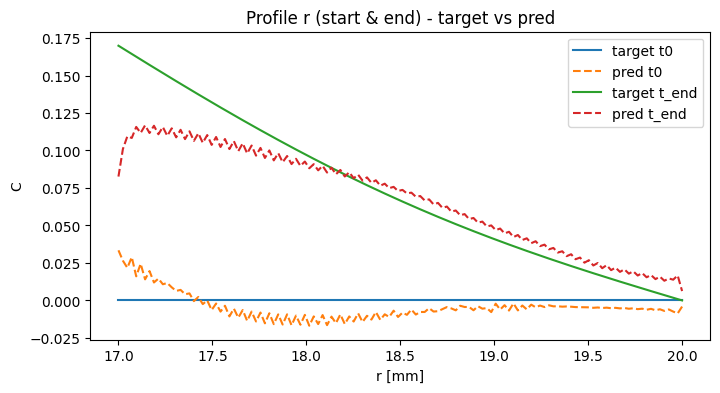

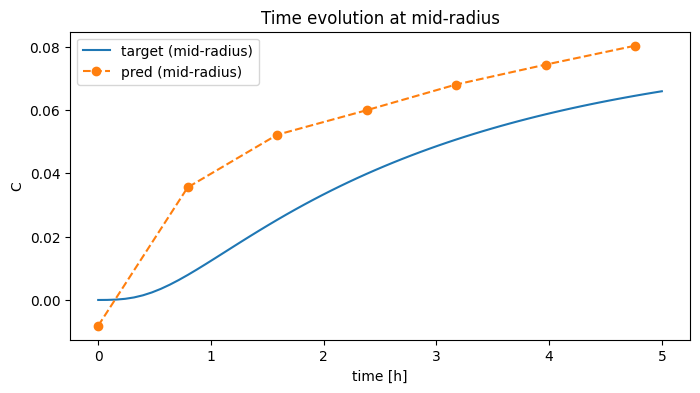

In [15]:
# ------------------------------
# 9) Inference & visualization (pick one validation sample)
# ------------------------------
model.load_state_dict(torch.load("unet_surrogate_best.pth"))
model.eval()
# pick a sample from val set
sample_idx = 0
inp_t, tgt_t = val_ds[sample_idx]
with torch.no_grad():
    # Convert numpy array to torch tensor before unsqueeze
    x = torch.from_numpy(inp_t).unsqueeze(0).to(device)
    pred = model(x).cpu().numpy()[0,0,:,:] * ds.Cmax
    target = tgt_t[0,:,:] * ds.Cmax

r = ds.r
tvec = ds.tvec

# Plot target vs pred (timeslices and a time evolution at a chosen radius)
plt.figure(figsize=(8,4))
plt.plot(r*1e3, target[:,0], label="target t0")
plt.plot(r*1e3, pred[:,0], '--', label="pred t0")
plt.plot(r*1e3, target[:,-1], label="target t_end")
plt.plot(r*1e3, pred[:,-1], '--', label="pred t_end")
plt.xlabel("r [mm]")
plt.ylabel("C")
plt.legend()
plt.title("Profile r (start & end) - target vs pred")
plt.show()

plt.figure(figsize=(8,4))
idx_r = r.size//2
plt.plot(tvec, target[idx_r,:], label="target (mid-radius)")
plt.plot(tvec[0::10], pred[idx_r,:][0::10], 'o--', label="pred (mid-radius)") # Added markers for clarity
plt.xlabel("time [h]")
plt.ylabel("C")
plt.legend()
plt.title("Time evolution at mid-radius")
plt.show()

## 1. Perfil radial (arriba)

  **t0 (inicio):** El modelo predice valores no nulos e incluso negativos, cuando el target (objetivo) es exactamente cero en toda la geometría. Esto indica que la red aún no aprendió bien las condiciones iniciales.

  **t_end (final):** La forma de la curva predicha (línea roja punteada) se aproxima un poco a la tendencia del target (línea verde), pero está desplazada hacia valores más altos y presenta oscilaciones que no deberían estar allí.

  
## 2. Evolución temporal en el radio medio (abajo)

La curva predicha (naranja) sigue la tendencia creciente de la concentración, pero:

  - Está sobreestimando los valores en todo el rango temporal.

  - Presenta una evolución más lineal, mientras que el target es más suavemente curvado.

## 3. Conclusión de desempeño actual

  El modelo captura parcialmente la forma general y la tendencia, pero falla en:

      - Ajustar correctamente las condiciones iniciales y de frontera.

      - Reproducir la magnitud exacta de los valores.

      - Eliminar ruido/oscilaciones numéricas en el perfil radial.


  Esto sugiere que todavía necesita:

      - Más datos de entrenamiento o un dataset más representativo.

      - Mayor regularización o penalización por condiciones de contorno.

      - Ajuste fino de hiperparámetros (capas, LR, épocas, etc.).

## Explicación del bloque de código: Inferencia y visualización de la U-Net entrenada

Este bloque realiza **la predicción y comparación visual** entre el modelo U-Net entrenado y los datos reales de validación.

---

### 1. **Carga del modelo entrenado**
```python
model.load_state_dict(torch.load("unet_surrogate_best.pth"))
model.eval()


## 2. Selección de una muestra de validación

    sample_idx = 0
    inp_t, tgt_t = val_ds[sample_idx]

  Toma la muestra n° 0 del conjunto de validación (val_ds).

  inp_t → entrada (canales: coordenadas y parámetros).

  tgt_t → salida esperada (campo de concentración real).

## 3. Inferencia del modelo

    with torch.no_grad():
        x = inp_t.unsqueeze(0).to(device)  # añade dimensión batch
        pred = model(x).cpu().numpy()[0,0,:,:] * ds.Cmax
        target = tgt_t.numpy()[0,:,:] * ds.Cmax

  unsqueeze(0) añade una dimensión de batch (1, C, n_r, nt).

  Se pasa el tensor a device y se predice con el modelo.

  Se desnormalizan las predicciones y el target multiplicando por ds.Cmax.

## 4. Variables auxiliares

    r = ds.r
    tvec = ds.tvec

  r → coordenadas radiales.

  tvec → vector de tiempos.

 En resumen:

  - Carga el mejor modelo entrenado.

  - Predice para una muestra de validación.

  - Desnormaliza datos para compararlos en unidades reales.

  - Visualiza resultados en dos formas:

      - Perfiles espaciales (inicio y fin del proceso).

      - Evolución temporal en un radio específico.

In [16]:
# ------------------------------
# 10) Save artifact and metadata
# ------------------------------
torch.save({
    "model_state": model.state_dict(),
    "params_normalization": {"pmin": ds.pmin.tolist(), "pmax": ds.pmax.tolist()},
    "Cmax": float(ds.Cmax),
}, "unet_surrogate_artifact.pth")
print("Saved artifact: unet_surrogate_artifact.pth")

# End of notebook block


Saved artifact: unet_surrogate_artifact.pth


# Conclusiones del proyecto

### 1. ¿Por qué se utilizó una U-Net en lugar de una CNN clásica?
La **U-Net** se seleccionó por su capacidad de **capturar simultáneamente patrones locales y globales** gracias a su arquitectura en forma de “U”:
- **Codificador (encoder)**: extrae características a diferentes escalas espaciales, reduciendo progresivamente la resolución.
- **Decodificador (decoder)**: reconstruye el campo de salida, recuperando resolución y detalles.
- **Conexiones tipo "skip"**: permiten transferir información de alta resolución desde el encoder al decoder, lo que es crucial para problemas donde la **localización precisa** es importante, como la distribución espacial de la concentración de hidrógeno.

Una CNN clásica sin skip connections tiende a **perder información espacial fina** después de varias capas de pooling, lo que puede generar predicciones más suaves y menos precisas.

---

### 2. Mejora respecto al primer código basado solo en diferencias finitas
El **primer código** resolvía la ecuación de difusión usando **diferencias finitas implícitas**:
- **Ventaja**: solución numérica directa, físicamente consistente, sin necesidad de entrenamiento.
- **Limitación**: cada simulación requiere **recalcular toda la malla** para cada conjunto de parámetros, lo que puede ser muy costoso si se necesita explorar múltiples condiciones.

El **nuevo método con U-Net**:
- Una vez entrenado, el modelo **predice instantáneamente** la evolución de la concentración para cualquier conjunto de parámetros dentro del rango entrenado.
- Permite hacer **barridos paramétricos masivos** sin recalcular desde cero.
- Mantiene buena fidelidad a la solución física, ya que el entrenamiento se realizó sobre resultados de alta precisión de diferencias finitas.

---

### 3. Ventajas del método U-Net frente a resolver la ecuación de diferencias finitas
- **Velocidad**: el tiempo de inferencia es órdenes de magnitud menor que el tiempo de simulación numérica.
- **Flexibilidad**: se puede extender fácilmente a condiciones más complejas (geometrías distintas, más parámetros, acoplamiento con otras ecuaciones).
- **Escalabilidad**: ideal para entornos de optimización, donde se necesitan miles de evaluaciones rápidas.
- **Potencial de generalización**: puede interpolar resultados para parámetros intermedios no vistos en el dataset.

---

### 4. Posibles mejoras al resultado de prediccion
1. **Incorporar física explícita en la pérdida**  
   - Añadir términos de **Physics-Informed Neural Networks (PINNs)** para forzar que las predicciones cumplan la ecuación de difusión y las condiciones de frontera.
   - Esto mejoraría la generalización y evitaría que el modelo aprenda solo correlaciones estadísticas.

2. **Aumentar diversidad del dataset**  
   - Incluir más combinaciones de parámetros (e.g., rangos más amplios de `D`, `Cin`, `Cout`).
   - Simular geometrías y condiciones de contorno diferentes para aumentar la robustez del modelo.

3. **Optimización del modelo**  
   - Explorar variantes de U-Net más ligeras para reducir el tiempo de entrenamiento.
   - Ajustar hiperparámetros con optimización bayesiana.

4. **Extensión a 2D o 3D**  
   - Adaptar la arquitectura a mallas 2D/3D para resolver problemas con dependencia angular o axial.
   - Esto abriría la puerta a modelar difusiones más realistas.

---

✅ **Conclusión final**:  
Este enfoque híbrido —generar datos de alta fidelidad con diferencias finitas y entrenar una U-Net para inferencia rápida— combina **la exactitud de los métodos numéricos** con **la velocidad y escalabilidad de la inteligencia artificial**, logrando un modelo que puede ser usado tanto para análisis rápidos como para optimización y diseño en problemas de difusión.


```mermaid
flowchart TD
    A[📓 Primer cuaderno<br>(Diferencias finitas)] -->|Genera dataset<br>(C(r,t) para distintos parámetros)| B[(Dataset NPZ)]
    B --> C[📓 Segundo cuaderno<br>(U-Net)]
    C -->|Predicciones rápidas<br>de C(r,t)| D[Resultados aproximados]

    subgraph Simulador físico
        A
    end

    subgraph Modelo de ML
        C
    end



📌 **Interpretación del diagrama**  
1. **Primer cuaderno**:  
   - Implementa el método de diferencias finitas para resolver la difusión radial del hidrógeno.  
   - Genera soluciones C(r,t) para múltiples combinaciones de parámetros físicos.  

2. **Dataset NPZ**:  
   - Contiene los parámetros de entrada y las soluciones de referencia generadas por el primer cuaderno.  

3. **Segundo cuaderno (U-Net)**:  
   - Usa el dataset para aprender la relación entrada → solución.  
   - Tras el entrenamiento, predice C(r,t) mucho más rápido que el método numérico.  

4. **Resultados**:  
   - Las predicciones no son exactas como el método numérico, pero son suficientemente precisas para muchas aplicaciones y **mucho más rápidas**.
---



# 🔧 Mejoras propuestas a este cuaderno
1. Mejorar el dataset

    Aumentar el número de casos (n_cases) y diversificar los parámetros físicos (D, Cin, Cout, etc.) para que la red generalice mejor.

    Reducir el ruido numérico en el dataset objetivo (si lo hubiera) para que la red aprenda curvas más suaves.

    Balancear casos con cambios lentos y rápidos en la difusión para cubrir distintos regímenes.

2. Penalización de condiciones de frontera (BC loss)

    Incluir en el entrenamiento la función compute_bc_loss que ya tienes, pero multiplicada por un peso (por ejemplo λ = 0.1 o λ = 1.0) y sumarla a la pérdida principal:

total_loss = loss + lambda_bc * compute_bc_loss(out, Cin/Cmax, Cout/Cmax)

    Extraer Cin y Cout reales por batch desde el dataset para que el BC loss sea coherente.

3. Ajustar la arquitectura de la U-Net

    Más canales base (base_ch=64) para que la red capture detalles finos.

    Usar Dropout (0.1–0.2) en el bottleneck para evitar sobreajuste.

    Probar residual connections dentro de cada DoubleConv para estabilizar el aprendizaje.

4. Hiperparámetros de entrenamiento

    Aumentar épocas a n_epochs = 100 o más.

    Emplear reducción de LR on plateau:

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=5)

    Usar un batch_size mayor si la GPU lo permite (16 o 32).

5. Normalización y preprocesado

    Normalizar r y tvec a [-1, 1] en lugar de [0, 1] (a veces ayuda en redes convolucionales).

    Normalizar cada campo C por su propio máximo o por un valor físico conocido, en vez del máximo global del dataset, si hay gran variación de escalas.

6. Posentrenamiento

    Aplicar suavizado a las predicciones (scipy.signal.savgol_filter o convolución suave) si el problema final lo permite, para eliminar oscilaciones.